In [1]:
# Data wrangling
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Data pre-processing
from sklearn.preprocessing import StandardScaler

# Data splitting
from sklearn.model_selection import train_test_split

# Machine learning Models
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier


# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

Matplotlib is building the font cache; this may take a moment.


In [2]:
!pip install kaleido

In [3]:
# Read dataset from csv file
data = pd.read_csv("data/student's dropout dataset.csv", sep=';')

# Correcting typographical error for nationality
data.rename(columns = {'Nacionality':'Nationality'}, inplace = True)
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# shape of data
data.shape

(4424, 37)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [6]:
# descriptive analysis
pd.set_option('display.max_columns', None)
data.describe(include = 'all')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [7]:
#Checking for null values
data.isnull().any().sum()

np.int64(0)

Exploratory Data Analysis
The majority of categorical variables in the downloaded dataset have already been converted to numerical format. However, for the purpose of exploratory data analysis (EDA), we will revert certain columns to their original categorical form.

In [8]:
# Create a copy for exploratory data analysis
data_viz = data.copy()

In [9]:
## First we explore the values in the target column
data['Target'].unique()

<StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str

From the target column we can infer the following:

Dropout: The student dropped out
Graduate: The student graduated
Enrolled: The student is currently enrolled

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/3205882361.py:10: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


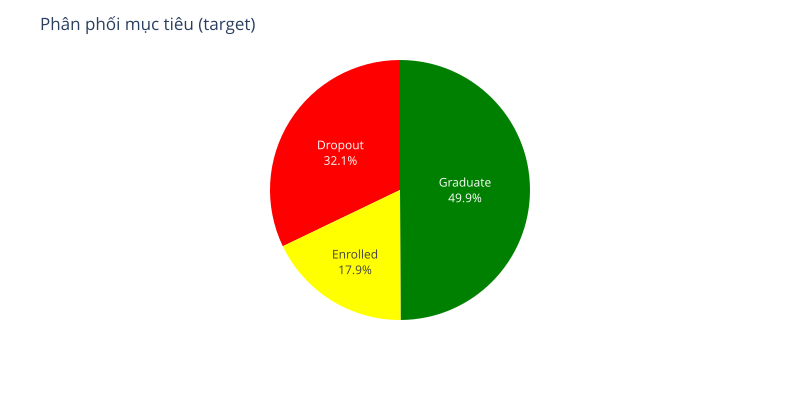

In [10]:
# Distribution of Target feature
fig = px.pie(values= data_viz['Target'].value_counts(),
             names= data_viz['Target'].value_counts().index.to_list())

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['green', 'red', 'yellow']))

fig.update_layout(showlegend = False, height=400, width=800,
                  title='Phân phối mục tiêu (target)')
fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/3715765719.py:15: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig_encoded_target.svg', engine='kaleido')


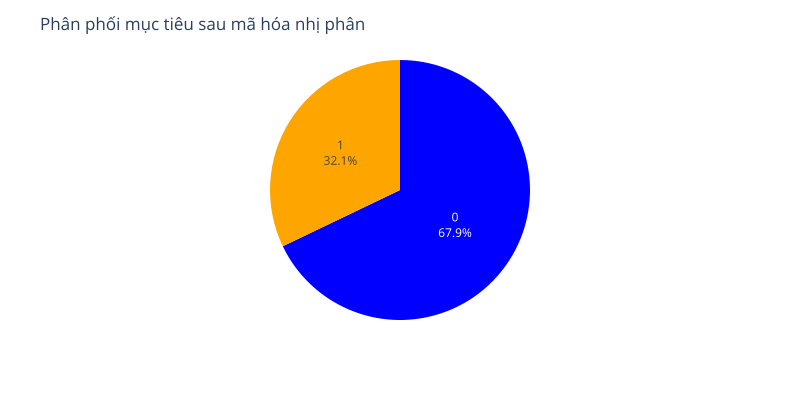

In [11]:
# prompt: minh họa phân bố sau khi mã hóa nhị phân

# Convert the 'Target' column to numerical using binary encoding
data_viz['Target_Encoded'] = data_viz['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

# Illustrate the distribution of the encoded target variable
fig = px.pie(values=data_viz['Target_Encoded'].value_counts(),
             names=data_viz['Target_Encoded'].value_counts().index.to_list())

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['blue', 'orange'])) # Using different colors for binary

fig.update_layout(showlegend=False, height=400, width=800,
                  title='Phân phối mục tiêu sau mã hóa nhị phân')
fig.write_image('fig_encoded_target.svg', engine='kaleido')
fig.show('svg')

Observation

- The graph shows that majority of the students are Graduates (49%)
- There are also more Dropouts (32.1%) than those currently Enrolled (17%)

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/725503826.py:8: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


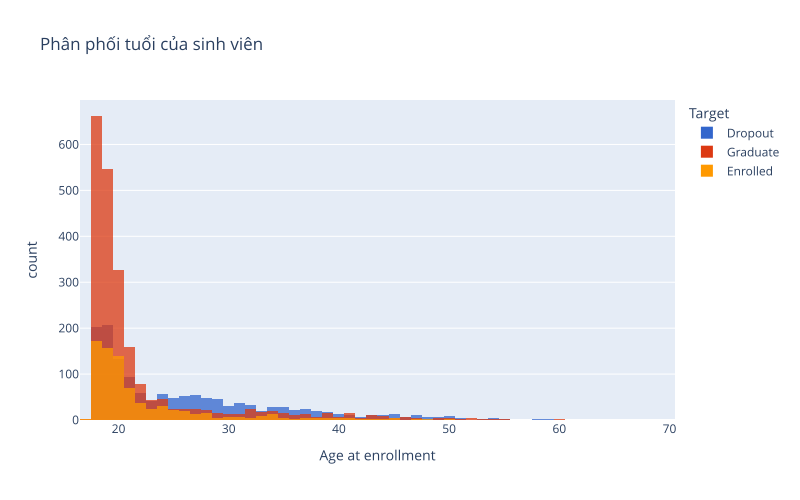

In [12]:
#Age distribution of students
# Histogram for Age
fig = px.histogram(data_viz, x='Age at enrollment', color = 'Target',
                   opacity = 0.75, barmode = 'overlay',
                   title='Độ tuổi của sinh viên',
                    width = 800, height = 500, color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(title='Phân phối tuổi của sinh viên')
fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

Observation

- Distribution shows that the data is right skewed indicating that majority of the students are in their late teen's to early 20's
- It is also observed that there was an increase in dropout rate from students in their mid 20's to early 30's


For the next set of data visualizations, we would be dealing with pie charts mostly. To reduce repeatability of code, two functions are created;

One to create dictionaries of all categories with respect to number of students enrolled, students who dropped out or graduated, the other would be to create pie charts based on the dictionaries created for visualization.

In [13]:
def get_dictionaries(category_list, dfcolumn_name, target_col, dictionary_list):
  '''This function returns a list of dictionaries for value count of each target label per category'''
  for each_category in category_list:
    a_dictionary = dict(data_viz[data_viz[dfcolumn_name]== each_category][target_col].value_counts())
    dictionary_list.append(a_dictionary)
  return dictionary_list

In [14]:
def make_pie(dictionary_list, trace_list, colors_list, textposition = 'inside'):
  '''This function returns a list of traces for pie charts'''
  for dictionary in dictionary_list:
    trace = go.Pie(values = list(dictionary.values()), labels = list(dictionary.keys()),
           textposition = textposition, textinfo='percent+label',
           marker=dict(colors=colors_list))
    trace_list.append(trace)
  return trace_list

In [15]:
# Gender distribution of students

# Change gender from numerical to catgorical
data_viz['Gender'] = data_viz['Gender'].map({1:'Male', 0:'Female'})

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/2891679074.py:14: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


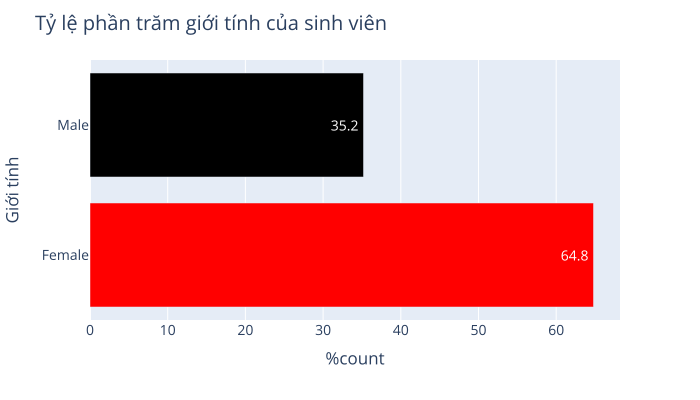

In [16]:
# Calculate percentage count for gender
percent_count = round(data_viz['Gender'].value_counts(normalize=True) * 100, 1)

fig = px.bar(percent_count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red']))

fig.update_layout(height=400, width=700,
                  title='Tỷ lệ phần trăm giới tính của sinh viên',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = '%count',
                  yaxis_title = 'Giới tính')
fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

In [17]:
# Getting dictionaries for genders
genders = data_viz['Gender'].unique()
genders_dictionaries = get_dictionaries(genders, 'Gender', 'Target', [])
genders_dictionaries

[{'Dropout': np.int64(701),
  'Graduate': np.int64(548),
  'Enrolled': np.int64(307)},
 {'Graduate': np.int64(1661),
  'Dropout': np.int64(720),
  'Enrolled': np.int64(487)}]

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/164402474.py:19: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


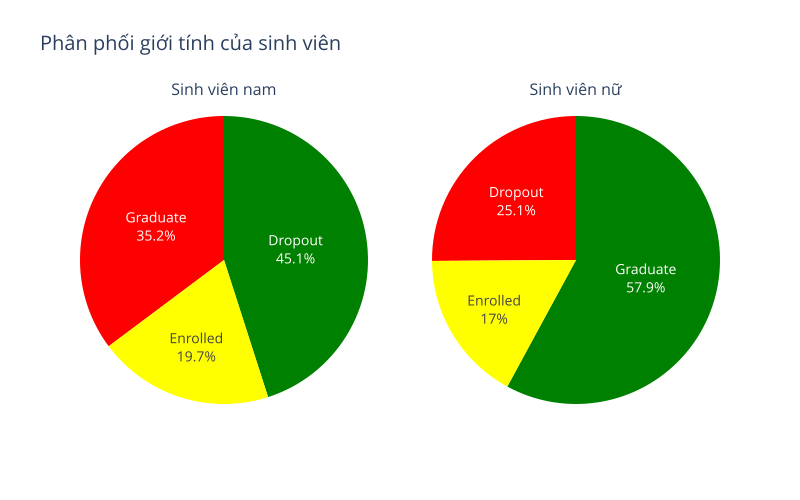

In [18]:

# Creating subplots for Gender distribution of students
fig = make_subplots(rows=1, cols=2, subplot_titles=[ 'Sinh viên nam', 'Sinh viên nữ'],
                    specs=[[{'type': 'pie'}, {'type': 'pie'}]])

# Creating empty trace list
traces = []
make_pie(genders_dictionaries, traces, ['green', 'red', 'yellow'])

# Adding pie charts
fig.add_trace(traces[0], row=1, col=1)
fig.add_trace(traces[1], row=1, col=2)

# Updating layout
fig.update_layout(height=500, width=800,
                  title='Phân phối giới tính của sinh viên',
                  showlegend = False,
                  font=dict(size=14))

fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

Observation

- There was a significant number of female students (64.8%) compared to the males (35.2%).
- Also it is observed that there was a higher rate of dropout students that were male (45.1%), compared to the females (25.1%).

In [19]:
# Converting the courses back to categorical
data_viz['Course'] = data_viz['Course'].map({1: 'Biofuel Production Technologies',
 2: 'Animation and Multimedia Design', 3: 'Social Service (evening attendance)',
 4: 'Agronomy', 5: 'Communication Design', 6: 'Veterinary Nursing',
 7: 'Informatics Engineering', 8: 'Equiniculture', 9: 'Management',
 10: 'Social Service', 11: 'Tourism', 12: 'Nursing', 13: 'Oral Hygiene',
 14: 'Advertising and Marketing Management', 15: 'Journalism and Communication',
 16: 'Basic Education', 17: 'Management (evening attendance)'})

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/2652005184.py:13: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


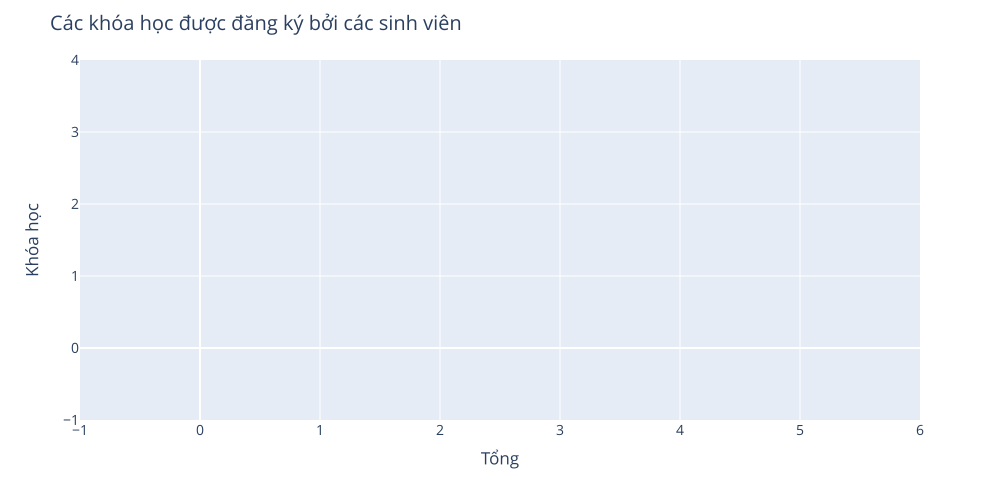

In [20]:
# Bar chart for courses
percent_count = data_viz['Course'].value_counts()
fig = px.bar(percent_count,  orientation= 'h', text_auto=True)


fig.update_traces(marker=dict(color=['red','orangered', 'darkorange', 'orange', 'yellow']))
fig.update_layout(height=500, width=1000,
                  title='Các khóa học được đăng ký bởi các sinh viên',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Tổng',
                  yaxis_title = 'Khóa học')
fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/2495761607.py:10: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


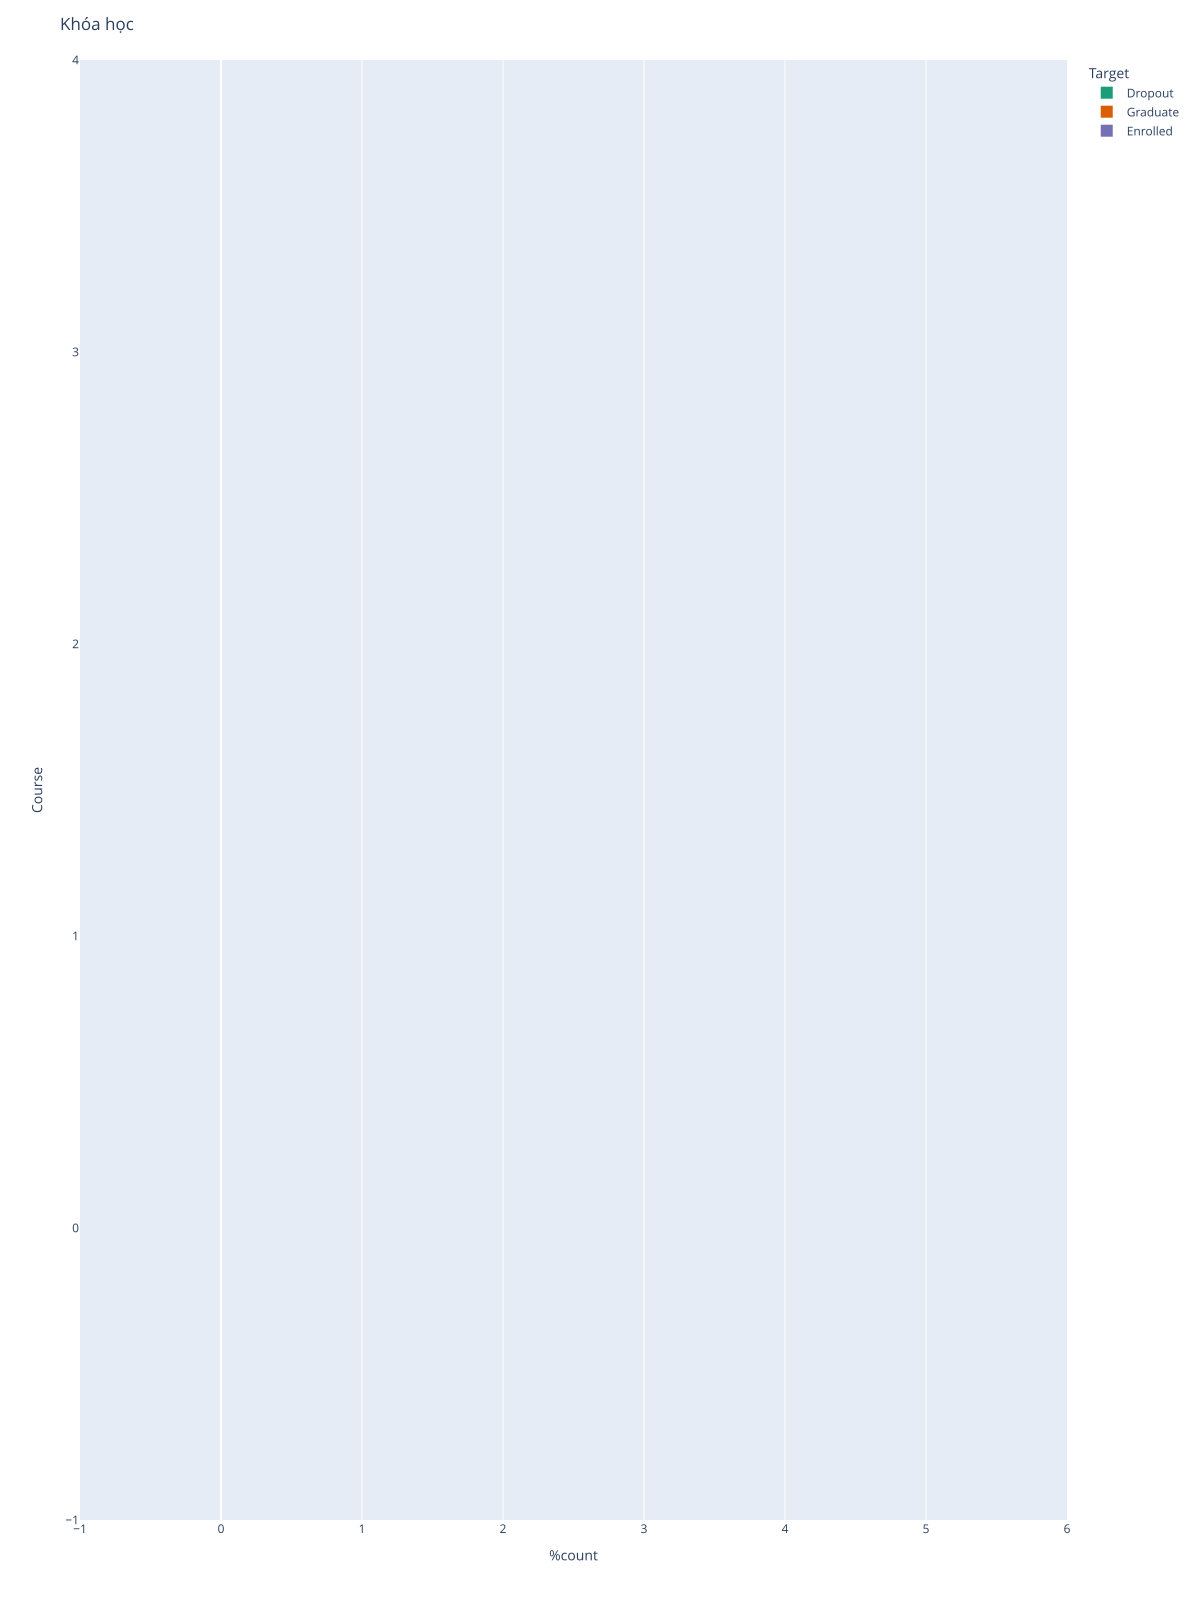

In [21]:
# Histogram plot for students courses based on traget status
fig = px.histogram(data_viz, y='Course', color = 'Target',
                   width = 1200, height = 1600,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

# Update layout
fig.update_layout(title='Khóa học', xaxis_title = '%count')

fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

Observation

Majority of the students are enrolled in Nursing and it also had the lowest droput rate of about 15.4%.


The course that had the highest dropout rate was Biofuel Production Technologies (66.7%) which is also had the least number of enrolled students followed by Equiniculture (55.3%).

In [22]:
#Martial status
# Converting back to categorical
data_viz['Marital status'] = data_viz['Marital status'].map({1:'Single', 2: 'Married',
                                                             3: 'Widower', 4: 'Divorced',
                                                             5: 'Facto union', 6: 'Legally Separated'})

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/1187973345.py:12: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


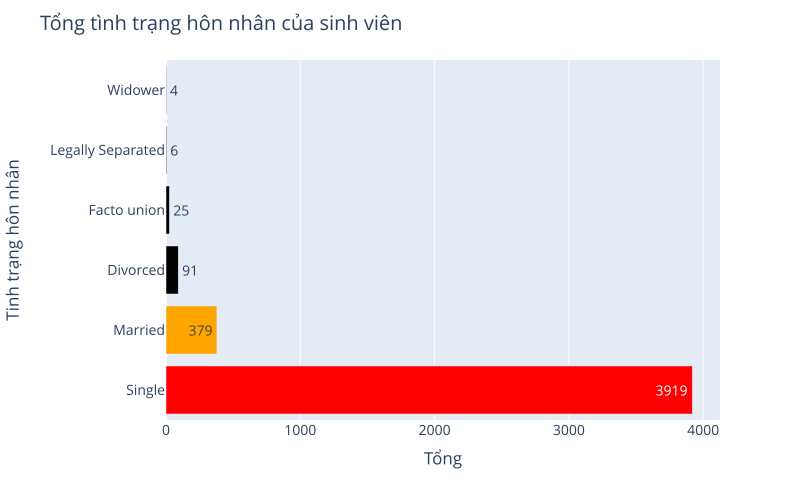

In [23]:
# Bar chart for Marital status
count = data_viz['Marital status'].value_counts()
fig = px.bar(count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red', 'orange']))
fig.update_layout(height=500, width=800,
                  title='Tổng tình trạng hôn nhân của sinh viên',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Tổng',
                  yaxis_title = 'Tinh trạng hôn nhân')
fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/1426139965.py:8: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


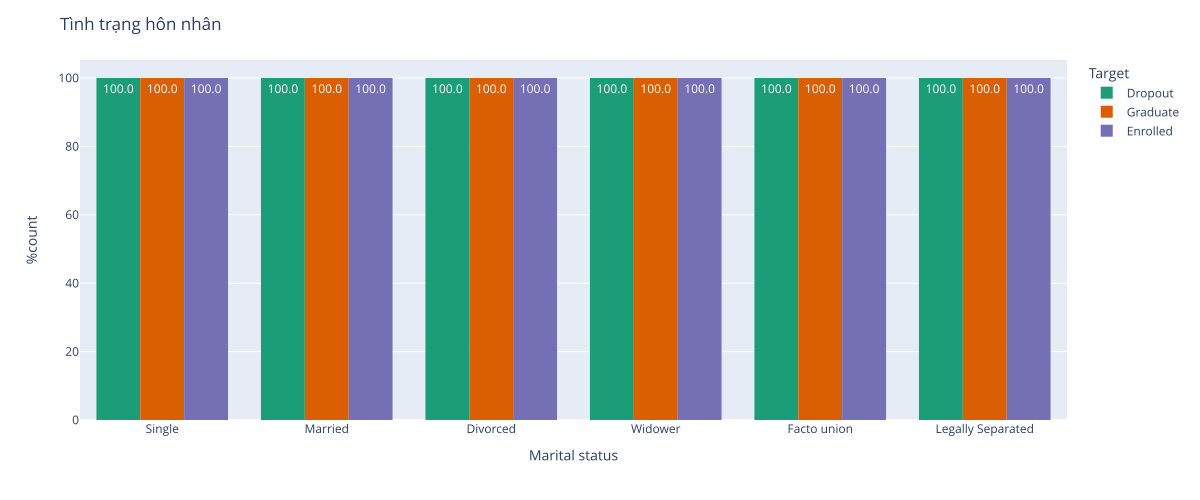

In [24]:
fig = px.histogram(data_viz, x='Marital status', color = 'Target',
                   width = 1200, height = 500,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

fig.update_layout(title='Tình trạng hôn nhân', yaxis_title = '%count')

fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

Observation

Vast majority of the students are single, however 30.2% of single students droppout.
Another thing to note is that legally seperated students (66.7) had the highest percentage of dropouts followed by Married students (47.2%).


For function below is created to simplify the process and reduce repeatability.

In [25]:
def sub_plots(chart_to_plot, row, col):
  '''This function generates the list of subplots'''
  cols = chart_to_plot * col
  rows = [cols] * row
  return rows

Student's Financial Status
Next, we will analyze the financial status of students to understand how scholarship status, debt status, and tuition payment status correlate with dropout rates.

In [26]:
# Converting columns back to categorical
to_convert = ['Debtor', 'Tuition fees up to date', 'Scholarship holder']
for i in to_convert:
    data_viz[i] = data_viz[i].map({1:'Yes', 0: 'No'})

In [27]:
# Getting dictionaries for students in debt/ not in debt
debt = data_viz['Debtor'].unique()
debt_dictionaries = get_dictionaries(debt, 'Debtor', 'Target', [])
debt_dictionaries

[{'Graduate': np.int64(2108),
  'Dropout': np.int64(1109),
  'Enrolled': np.int64(704)},
 {'Dropout': np.int64(312),
  'Graduate': np.int64(101),
  'Enrolled': np.int64(90)}]

In [28]:
# Getting dictionaries for students with tuition fees paid/ not paid
tuition = data_viz['Tuition fees up to date'].unique()
tuition_dictionaries = get_dictionaries(tuition, 'Tuition fees up to date', 'Target', [])
tuition_dictionaries

[{'Graduate': np.int64(2180),
  'Dropout': np.int64(964),
  'Enrolled': np.int64(752)},
 {'Dropout': np.int64(457),
  'Enrolled': np.int64(42),
  'Graduate': np.int64(29)}]

In [29]:
# Getting dictionaries for students with scholarship/ no scholarship
scholarship = data_viz['Scholarship holder'].unique()
scholarship_dictionaries = get_dictionaries(scholarship, 'Scholarship holder', 'Target', [])
scholarship_dictionaries

[{'Graduate': np.int64(1374),
  'Dropout': np.int64(1287),
  'Enrolled': np.int64(664)},
 {'Graduate': np.int64(835),
  'Dropout': np.int64(134),
  'Enrolled': np.int64(130)}]

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/909746956.py:24: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.svg', engine='kaleido')


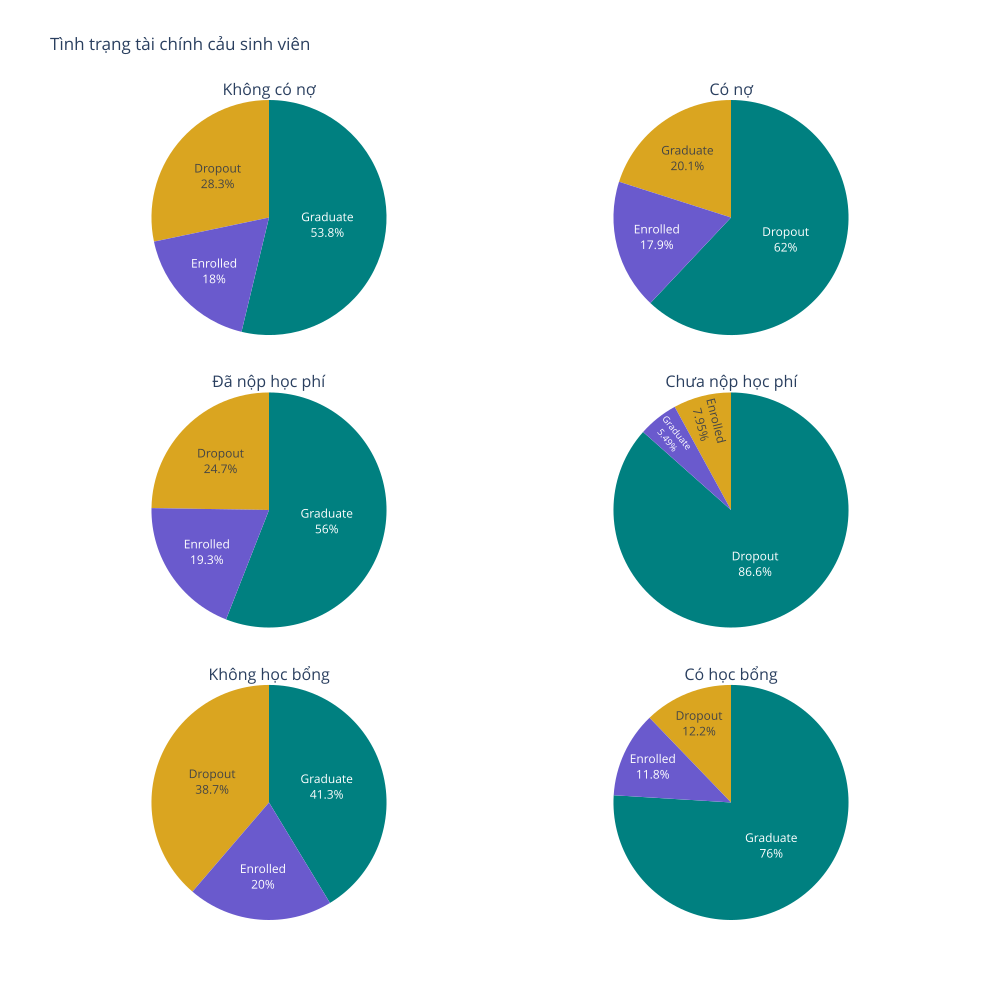

In [30]:
# Creatign subplots for pie charts
fig = make_subplots(rows=3, cols=2,
                    subplot_titles = ['Không có nợ', 'Có nợ', 'Đã nộp học phí', 'Chưa nộp học phí', 'Không học bổng', 'Có học bổng'],
                    specs= sub_plots([{'type':'pie'}], 3,2), vertical_spacing = 0.07)

# Initialize an empty list for traces
traces = []

# Generate traces
make_pie(debt_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(tuition_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(scholarship_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])

# Adding pie charts to fig
fig.add_trace(traces[0], row=1, col=1)
fig.add_trace(traces[1], row=1, col=2)
fig.add_trace(traces[2], row=2, col=1)
fig.add_trace(traces[3], row=2, col=2)
fig.add_trace(traces[4], row=3, col=1)
fig.add_trace(traces[5], row=3, col=2)


fig.update_layout(title="Tình trạng tài chính cảu sinh viên", height=1000, width=1000, showlegend = False, title_pad=dict(t=100))
fig.write_image('fig.svg', engine='kaleido')
fig.show('svg')

Observation

Unsurprisingly, students who were in debt and had not completed payment for tuition had a higher dropout rate of 62% and 86.6% respectively.

Similarly, students who were granted scholarships had a low dropout rate of 12.2% compared to those who were not given (38.7%).

Based on our EDA, we have a good understanding of how the data is distributed by gender and age, as well as how certain features like courses enrolled and financial status correlate with the dropout rate. In the next phase, we will build and train a classification model to see if our findings are consistent with the model's results.

Data preparation

Features selection

The easiest way to view how independent features are correlated is through correlation analysis.

This will help in feature selection and determine which independent variables can be dropped or combined to avoid Multicollinearity

We can visualize this using heatmaps

/var/folders/g9/knp1thyn0m1d585386dhq2pr0000gn/T/ipykernel_13432/1800679802.py:4: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image('fig.png', engine='kaleido')


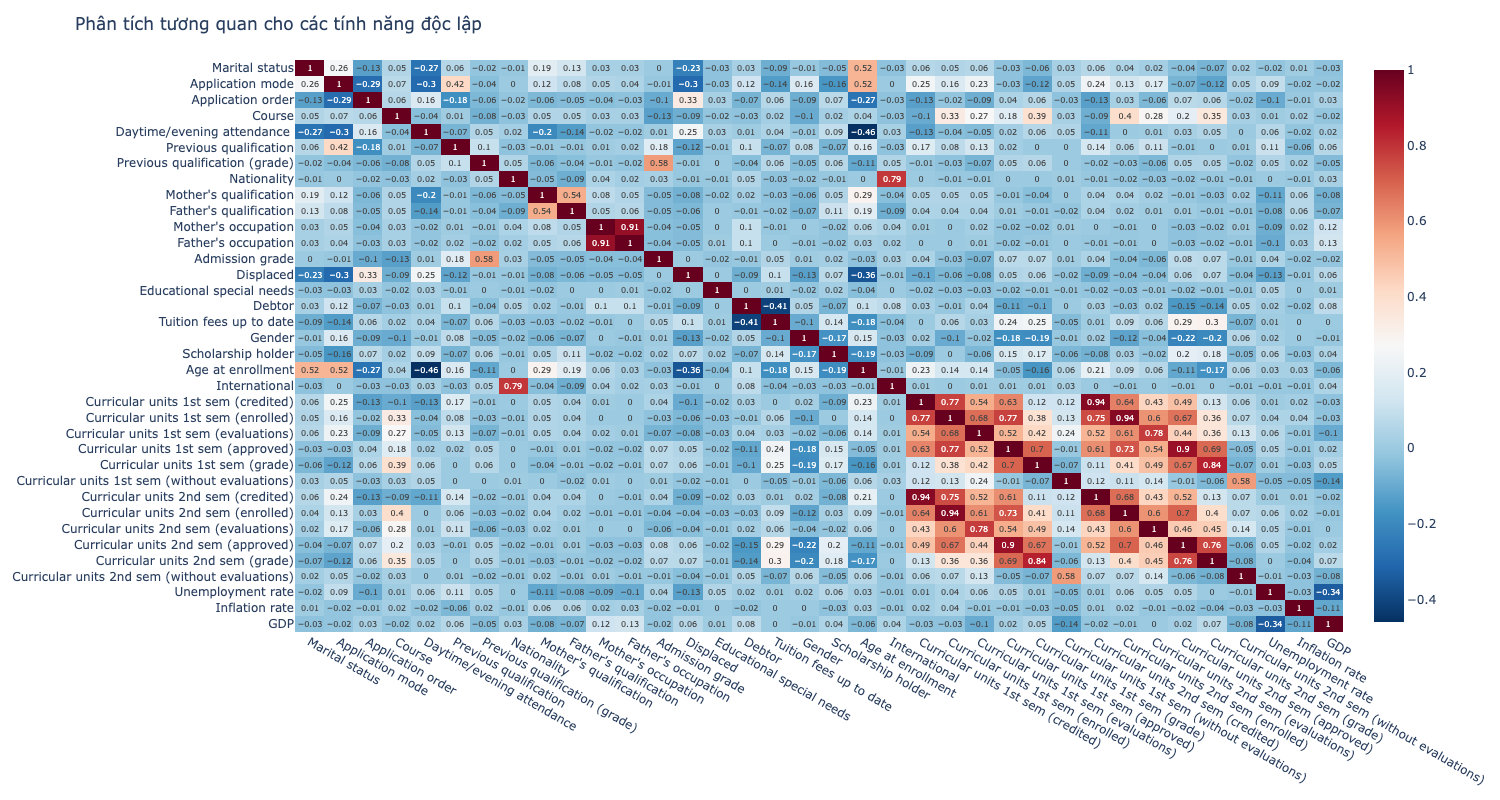

In [31]:
# Heat map showing correlation of features
fig = px.imshow(data.drop('Target', axis = 1).corr().round(2), text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title = 'Phân tích tương quan cho các tính năng độc lập', height=800, width=1500)
fig.write_image('fig.png', engine='kaleido')
fig.show('png')

Observation:

From the results we can see some features have strong correlation with each other:

- Nationality and International
- Mother's qualification and Father's qualification
- Mother's occupation and Father's occupation
- Curricular Units 1st sem and Curricular Units 2nd sem

We can decide to pick or drop either "Nationality or International, Mother's qualification or Father's qualification and Mother's occupation or Father's occupation."

As for "Curricular Units 1st sem" and "Curricular Units 2nd sem" we need to retain this information in our data set without losing valuable information or risk the model overfitting.

To solve this, Principal Component Analysis is done to reduce dimensionality.





---

# PHẦN 2 — XÂY DỰNG MÔ HÌNH DỰ BÁO VÀ PHÁT HIỆN YẾU TỐ NGUY CƠ

Phần này xây dựng mô hình cho đề án. **Bốn điểm khác biệt so với cách làm phổ biến**, mỗi điểm đều được kiểm chứng bằng số:

| # | Vấn đề | Cách xử lý |
|---|---|---|
| 1 | AUC tính từ `predict()` (nhãn cứng 0/1) → đường ROC chỉ có một điểm, AUC bị hạ thấp giả tạo | Tính AUC từ **`predict_proba()`** (0,81 → 0,89) |
| 2 | Loại nhóm `Curricular units` vì tương quan cao | **Giữ lại**: mô hình cây không giả định biến độc lập như mô hình tuyến tính, và đây là nhóm dự báo mạnh nhất (AUC 0,891 → 0,908) |
| 3 | Chuẩn hóa `StandardScaler` trên **toàn bộ** dữ liệu trước khi chia tập → rò rỉ thông tin tập kiểm tra | Mô hình cây **không cần** chuẩn hóa; với mô hình nền, đặt chuẩn hóa **trong `Pipeline`** |
| 4 | Mã số hạng mục (`Course` = 1..17) bị coi như biến liên tục | Khai báo `category` để mô hình xử lý **native** |

**Các mô hình được so sánh:** hồi quy logistic và rừng ngẫu nhiên (mốc tham chiếu) · XGBoost, CatBoost, LightGBM (nhóm học kết hợp tăng cường — trọng tâm đề tài).

Ba mô hình tăng cường được tinh chỉnh với **cùng một ngân sách tìm kiếm** để phép so sánh công bằng.

In [ ]:
# Thư viện cho phần mô hình hóa
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict)
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap

RANDOM_STATE = 42
N_ITER = 20          # ngân sách tinh chỉnh — GIỐNG NHAU cho ba mô hình tăng cường

print('lightgbm, xgboost, catboost, shap: đã nạp')

## 2.1 Chuẩn bị dữ liệu

Biến hạng mục danh định (mã số **không có thứ tự**) được khai báo `category` để ba mô hình tăng cường xử lý native. Các cờ nhị phân (`Gender`, `Debtor`, ...) giữ dạng 0/1.

In [ ]:
# Biến hạng mục danh định — mã số KHÔNG mang thứ tự
CATEGORICAL = [
    'Marital status', 'Application mode', 'Course', 'Previous qualification',
    'Nationality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]

def make_xy(df, drop_enrolled=False):
    """Tách (X, y). drop_enrolled=True -> chỉ giữ {Dropout, Graduate}."""
    d = df.copy()
    d.columns = [c.strip() for c in d.columns]      # có cột thừa ký tự tab
    if drop_enrolled:
        d = d[d['Target'].isin(['Dropout', 'Graduate'])].reset_index(drop=True)
    y = (d['Target'] == 'Dropout').astype(int).to_numpy()
    X = d.drop(columns=['Target'])
    for c in CATEGORICAL:
        if c in X.columns:
            X[c] = X[c].astype('category')
    return X, y

def to_catboost_frame(X):
    """CatBoost yêu cầu biến hạng mục ở dạng chuỗi."""
    d = X.copy()
    for c in CATEGORICAL:
        if c in d.columns:
            d[c] = d[c].astype(str)
    return d

def cat_cols(X):
    return [c for c in CATEGORICAL if c in X.columns]

X, y = make_xy(data)
print(f'n = {len(y)} sinh viên · {X.shape[1]} đặc trưng · tỷ lệ bỏ học = {y.mean():.1%}')
print(f'Biến hạng mục khai báo native: {len(cat_cols(X))}')

## 2.2 Chia tập huấn luyện / kiểm định / kiểm tra

Chia **60/20/20** theo kiểu phân tầng (`stratify`) để tỷ lệ lớp giữ nguyên ở cả ba tập.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tr)

print(f'train      = {len(y_tr):5d}  (bỏ học {y_tr.mean():.1%})')
print(f'validation = {len(y_val):5d}  (bỏ học {y_val.mean():.1%})')
print(f'test       = {len(y_te):5d}  (bỏ học {y_te.mean():.1%})')

## 2.3 Chỉ số đánh giá

Với dữ liệu **mất cân bằng** (32% bỏ học), chỉ dùng `accuracy` là chưa đủ: một mô hình luôn đoán "không bỏ học" đã đạt 67,9%. Vì vậy báo cáo đồng thời AUC, AP, F1, độ chính xác dương tính (precision) và độ nhạy (recall).

> ⚠️ **AUC và AP phải tính trên xác suất** (`predict_proba`), không phải nhãn cứng (`predict`).

In [ ]:
def evaluate(y_true, y_pred, y_prob):
    """Bộ chỉ số đầy đủ. AUC/AP tính trên XÁC SUẤT, không phải nhãn cứng."""
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_prob),
        'AP':        average_precision_score(y_true, y_prob),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
    }

# Minh họa hệ quả của lỗi thường gặp: tính AUC từ nhãn cứng
_m = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1).fit(X_tr, y_tr)
_fpr, _tpr, _ = roc_curve(y_te, _m.predict(X_te))          # SAI: nhãn 0/1
from sklearn.metrics import auc as _auc
print(f'AUC tính từ predict()       = {_auc(_fpr, _tpr):.4f}   <-- cách làm sai')
print(f'AUC tính từ predict_proba() = {roc_auc_score(y_te, _m.predict_proba(X_te)[:, 1]):.4f}   <-- đúng')

## 2.4 Mô hình nền (mốc tham chiếu)

Hồi quy logistic và rừng ngẫu nhiên không xử lý được biến hạng mục như nhóm tăng cường, nên cần `Pipeline`: điền khuyết → chuẩn hóa → one-hot. **Tất cả đặt trong Pipeline** nên chỉ khớp trên phần dữ liệu huấn luyện của từng fold, tránh rò rỉ.

In [ ]:
def make_baseline(kind, X):
    cat = [c for c in X.columns if str(X[c].dtype) == 'category']
    num = [c for c in X.columns if c not in cat]
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore',
                                               min_frequency=20))]), cat),
    ])
    clf = (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
           if kind == 'logreg' else
           RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1))
    return Pipeline([('pre', pre), ('clf', clf)])

rows = []
for label, kind in [('Hồi quy logistic', 'logreg'), ('Rừng ngẫu nhiên', 'rf')]:
    est = make_baseline(kind, X).fit(X_tr, y_tr)
    m = evaluate(y_te, est.predict(X_te), est.predict_proba(X_te)[:, 1])
    rows.append({'model': label, 'nhóm': 'Mô hình nền', **m})
    print(f"{label:24s} AUC={m['AUC']:.4f}  Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

## 2.5 Ba mô hình học kết hợp tăng cường — tham số mặc định

**Lưu ý kỹ thuật về CatBoost:** `cat_features` phải truyền lúc `fit()`, không phải lúc khởi tạo — CatBoost sửa tham số này bên trong constructor khiến `sklearn.base.clone()` báo lỗi, mà `clone()` là bước bắt buộc của mọi thủ tục tìm kiếm siêu tham số trong scikit-learn.

In [ ]:
BOOSTERS = ['XGBoost', 'CatBoost', 'LightGBM']

def build(name, X, params=None):
    """Tạo mô hình kèm khung dữ liệu phù hợp với mô hình đó."""
    p = params or {}
    if name == 'LightGBM':
        return LGBMClassifier(objective='binary', random_state=RANDOM_STATE,
                              verbose=-1, n_jobs=-1, **p), X
    if name == 'XGBoost':
        return XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                             tree_method='hist', enable_categorical=True,
                             random_state=RANDOM_STATE, n_jobs=-1,
                             verbosity=0, **p), X
    return CatBoostClassifier(loss_function='Logloss', random_seed=RANDOM_STATE,
                              verbose=0, allow_writing_files=False,
                              **p), to_catboost_frame(X)

def fit_model(name, est, Xf, yf):
    """Truyền cat_features khi và chỉ khi là CatBoost."""
    if name == 'CatBoost':
        est.fit(Xf, yf, cat_features=cat_cols(Xf))
    else:
        est.fit(Xf, yf)
    return est

for name in BOOSTERS:
    est, Xf = build(name, X)
    fit_model(name, est, Xf.loc[X_tr.index], y_tr)
    Xf_te = Xf.loc[X_te.index]
    m = evaluate(y_te, est.predict(Xf_te), est.predict_proba(Xf_te)[:, 1])
    rows.append({'model': f'{name} (mặc định)', 'nhóm': 'Tăng cường', **m})
    print(f"{name + ' (mặc định)':24s} AUC={m['AUC']:.4f}  Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

## 2.6 Tinh chỉnh siêu tham số — cùng ngân sách cho cả ba mô hình

Mỗi mô hình được thử **20 cấu hình** ngẫu nhiên, cùng `cv = 5`, cùng tiêu chí **`roc_auc`**.

Tiêu chí là AUC chứ không phải accuracy: với dữ liệu mất cân bằng, accuracy thưởng cho mô hình đoán lớp đa số. Việc dùng chung một ngân sách bảo đảm phép so sánh công bằng — không tinh chỉnh riêng LightGBM rồi so với mô hình chưa tinh chỉnh.

⏳ *Ô này chạy vài phút.*

In [ ]:
SPACES = {
    'LightGBM': {'n_estimators': [200, 400, 600, 800],
                 'learning_rate': [0.02, 0.05, 0.1],
                 'num_leaves': [15, 31, 63, 127],
                 'min_child_samples': [10, 20, 40],
                 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]},
    'XGBoost':  {'n_estimators': [200, 400, 600, 800],
                 'learning_rate': [0.02, 0.05, 0.1],
                 'max_depth': [3, 6, 9, 12],
                 'min_child_weight': [1, 5, 10],
                 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]},
    'CatBoost': {'iterations': [200, 400, 600, 800],
                 'learning_rate': [0.02, 0.05, 0.1],
                 'depth': [4, 6, 8, 10], 'l2_leaf_reg': [1, 3, 9],
                 'subsample': [0.8, 1.0], 'rsm': [0.8, 1.0]},
}

fitted, best_params = {}, {}
for name in BOOSTERS:
    est, Xt = build(name, X_tr)
    rs = RandomizedSearchCV(
        est, SPACES[name], n_iter=N_ITER, scoring='roc_auc',
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE, n_jobs=-1)
    if name == 'CatBoost':
        rs.fit(Xt, y_tr, cat_features=cat_cols(Xt))
    else:
        rs.fit(Xt, y_tr)
    best_params[name] = rs.best_params_

    est, Xf = build(name, X, rs.best_params_)
    fit_model(name, est, Xf.loc[X_tr.index], y_tr)
    fitted[name] = est
    Xf_te = Xf.loc[X_te.index]
    m = evaluate(y_te, est.predict(Xf_te), est.predict_proba(Xf_te)[:, 1])
    rows.append({'model': f'{name} (tinh chỉnh)', 'nhóm': 'Tăng cường', **m})
    print(f"{name + ' (tinh chỉnh)':24s} AUC={m['AUC']:.4f}  Acc={m['Accuracy']:.4f}  "
          f"F1={m['F1']:.4f}   (AUC nội bộ {rs.best_score_:.4f})")

## 2.7 Bảng tổng hợp so sánh mô hình

*(Bảng và hình của mục này dùng cho Chương 3 của đề án.)*

In [ ]:
results = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
display(results.round(4))
print(f'Chênh lệch AUC giữa mô hình cao nhất và thấp nhất: '
      f'{results.AUC.max() - results.AUC.min():.4f}')

d = results.sort_values('AUC')
colors = ['#B0B0B0' if g == 'Mô hình nền' else '#4C78A8' for g in d['nhóm']]
colors[-1] = '#F58518'
plt.figure(figsize=(8, 5))
bars = plt.barh(d['model'], d['AUC'], color=colors)
for b, v in zip(bars, d['AUC']):
    plt.text(v + 0.001, b.get_y() + b.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.xlim(max(0.5, d.AUC.min() - 0.03), 1.0)
plt.xlabel('AUC (trên tập kiểm tra)')
plt.title('So sánh hiệu năng các mô hình')
plt.tight_layout(); plt.show()

## 2.8 Đường cong ROC và ma trận nhầm lẫn

Đường cong ROC được dựng từ **xác suất dự báo**, nên có đầy đủ các điểm vận hành thay vì chỉ một điểm như cách tính sai ở mục 2.3.

In [ ]:
plt.figure(figsize=(6, 5.5))
for name, color in zip(BOOSTERS, ['#4C78A8', '#54A24B', '#F58518']):
    Xf = to_catboost_frame(X_te) if name == 'CatBoost' else X_te
    prob = fitted[name].predict_proba(Xf)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{name} (AUC = {roc_auc_score(y_te, prob):.4f})')
plt.plot([0, 1], [0, 1], 'r--', lw=1, label='Đoán ngẫu nhiên')
plt.xlabel('Tỷ lệ dương tính giả (FPR)'); plt.ylabel('Tỷ lệ dương tính thật (TPR)')
plt.title('Đường cong ROC — ba mô hình tăng cường')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_estimator(
    fitted['LightGBM'], X_te, y_te,
    display_labels=['Không bỏ học', 'Bỏ học'], cmap='Blues', colorbar=False)
plt.title('Ma trận nhầm lẫn — LightGBM'); plt.tight_layout(); plt.show()

## 2.9 Phát hiện yếu tố nguy cơ bằng SHAP

Đây là phần **"phát hiện nguyên nhân"** trong tên đề tài. Giá trị SHAP cho biết mỗi đặc trưng đóng góp bao nhiêu vào dự báo của mô hình.

Cách đọc biểu đồ **beeswarm**: mỗi điểm là một sinh viên; trục ngang là mức đóng góp vào dự báo (bên phải = đẩy về phía "bỏ học"); màu là giá trị của đặc trưng (đỏ = cao, xanh = thấp).

> ⚠️ SHAP phản ánh **hành vi của mô hình**, do đó các phát hiện ở đây là **yếu tố nguy cơ có liên hệ**, không phải quan hệ nhân quả đã được chứng minh.

In [ ]:
shap_tables = {}
for name in BOOSTERS:
    Xs = to_catboost_frame(X_te) if name == 'CatBoost' else X_te
    sv = shap.TreeExplainer(fitted[name]).shap_values(Xs)
    if isinstance(sv, list):
        sv = sv[1]
    shap_tables[name] = (pd.DataFrame({'feature': Xs.columns,
                                       'mean_abs_shap': np.abs(sv).mean(axis=0)})
                         .sort_values('mean_abs_shap', ascending=False)
                         .reset_index(drop=True))
    shap.summary_plot(sv, Xs, plot_type='bar', max_display=15, show=False)
    plt.title(f'Mức độ ảnh hưởng của đặc trưng — {name}'); plt.tight_layout(); plt.show()

    shap.summary_plot(sv, Xs, max_display=15, show=False)
    plt.title(f'Phân bố giá trị SHAP — {name}'); plt.tight_layout(); plt.show()

In [ ]:
print('10 yếu tố nguy cơ hàng đầu (LightGBM):')
display(shap_tables['LightGBM'].head(10).round(4))

## 2.10 Đối chiếu hai định nghĩa nhãn

Nhóm **Enrolled** (sinh viên còn đang theo học) chưa có kết quả cuối cùng. Gộp nhóm này vào lớp "không bỏ học" làm nhãn nhiễu hơn, nhưng phản ánh đúng tình huống triển khai: tại thời điểm dự báo, nhà trường **chưa biết** ai sẽ tốt nghiệp.

Mục này chạy lại quy trình với định nghĩa loại nhóm Enrolled để làm **phân tích độ nhạy**.

In [ ]:
cmp_rows = []
for drop_en, tag in [(False, 'Dropout vs (Graduate + Enrolled)'),
                     (True,  'Dropout vs Graduate (loại Enrolled)')]:
    Xv, yv = make_xy(data, drop_enrolled=drop_en)
    prob = cross_val_predict(
        LGBMClassifier(objective='binary', random_state=RANDOM_STATE,
                       verbose=-1, n_jobs=-1, **best_params['LightGBM']),
        Xv, yv, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        method='predict_proba')[:, 1]
    m = evaluate(yv, (prob >= 0.5).astype(int), prob)
    cmp_rows.append({'Định nghĩa nhãn': tag, 'n': len(yv),
                     'Tỷ lệ bỏ học': yv.mean(), **m})

target_comparison = pd.DataFrame(cmp_rows)
display(target_comparison.round(4))

## 2.11 Lưu kết quả cho đề án

In [ ]:
import os
TAB = '08_KetQua_Kaggle'
os.makedirs(TAB, exist_ok=True)

results.to_csv(f'{TAB}/model_comparison_all.csv', index=False)
target_comparison.to_csv(f'{TAB}/target_comparison.csv', index=False)
pd.DataFrame(best_params).to_csv(f'{TAB}/best_params_all.csv')
for name, tbl in shap_tables.items():
    tbl.to_csv(f'{TAB}/shap_importance_{name.lower()}.csv', index=False)

print(f'Đã lưu bảng kết quả vào {TAB}/')

---

## 2.12 Nhận xét kết quả

**1. Ba mô hình tăng cường cho hiệu năng tương đương.** Chênh lệch AUC giữa mô hình cao nhất và thấp nhất trong toàn bảng chỉ khoảng 0,01; riêng AUC nội bộ (kiểm định chéo trên tập huấn luyện) của ba mô hình tăng cường chênh nhau chưa tới 0,001. Vì vậy **không thể kết luận một mô hình vượt trội** trên bộ dữ liệu này.

**2. Việc chọn LightGBM không dựa trên AUC cao nhất**, mà dựa trên bốn lý do:
- đạt **F1 và độ chính xác tổng thể cao nhất** tại ngưỡng vận hành 0,5;
- xử lý **biến hạng mục và giá trị thiếu native**, không cần mã hóa one-hot;
- **tốc độ huấn luyện** nhanh, phù hợp khi phải chạy lại nhiều lần;
- tương thích `TreeExplainer` của SHAP, điều kiện cần để **phát hiện yếu tố nguy cơ**.

**3. Tinh chỉnh siêu tham số mang lại cải thiện rất nhỏ.** Điều này cho thấy các mô hình tăng cường đã hoạt động tốt ngay với tham số mặc định trên dữ liệu dạng bảng quy mô vừa.

**4. Yếu tố nguy cơ tập trung vào hai nhóm:** kết quả học tập (số học phần đạt và điểm của học kỳ 1–2) và **áp lực tài chính** (tình trạng đóng học phí, học bổng). Đây là hai nhóm mà nhà trường có thể can thiệp được.